In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

from skimage.feature import local_binary_pattern

import os
from PIL import Image
import glob

from skimage.feature import hog
import warnings
warnings.filterwarnings("ignore")

# Cats and Dogs Dataset

In [2]:
# for kaggle api
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
# downaloding data from kaggle
!kaggle competitions download -c dogs-vs-cats -p ./dogs_vs_cats

 99% 805M/812M [00:07<00:00, 43.1MB/s]
100% 812M/812M [00:07<00:00, 117MB/s] 


In [4]:
!unzip /content/dogs_vs_cats/dogs-vs-cats.zip

!unzip -q train.zip

Archive:  /content/dogs_vs_cats/dogs-vs-cats.zip
  inflating: sampleSubmission.csv    
  inflating: test1.zip               
  inflating: train.zip               


In [5]:
os.makedirs("data/train/cats", exist_ok=True)
os.makedirs("data/train/dogs", exist_ok=True)

!mv train/cat.* data/train/cats/
!mv train/dog.* data/train/dogs/

In [6]:
from PIL import Image

def preprocessing_df(data_path):
    data = []

    for cls in os.listdir(data_path):
        cls_path = os.path.join(data_path, cls)

        if os.path.isdir(cls_path):
            label = 0 if cls == "cats" else 1

            for img_name in os.listdir(cls_path):
                img_path = os.path.join(cls_path, img_name)

                data.append({"image_path": img_path, "label": label})

    df = pd.DataFrame(data)
    return df



data_path = "/content/data/train"
df = preprocessing_df(data_path)
df.head()

,image_path,label
0,/content/data/train/cats/cat.1164.jpg,0
1,/content/data/train/cats/cat.9994.jpg,0
2,/content/data/train/cats/cat.8293.jpg,0
3,/content/data/train/cats/cat.6979.jpg,0
4,/content/data/train/cats/cat.185.jpg,0


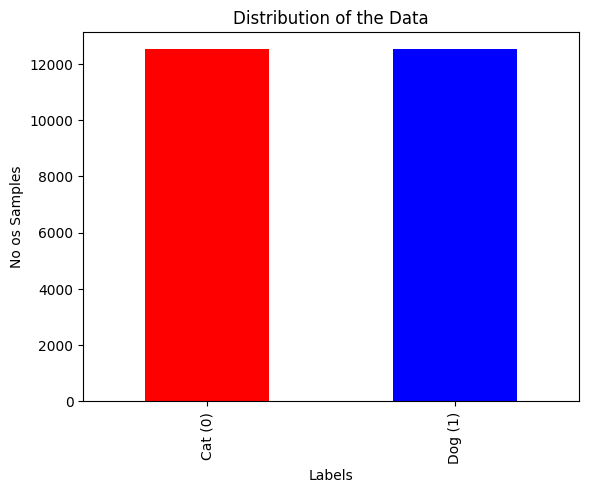

In [7]:
df["label"].value_counts().plot(kind="bar",color=["red","blue"])
plt.title("Distribution of the Data")
plt.xticks([0,1], ["Cat (0)", "Dog (1)"])
plt.xlabel("Labels")
plt.ylabel("No os Samples")
plt.show()

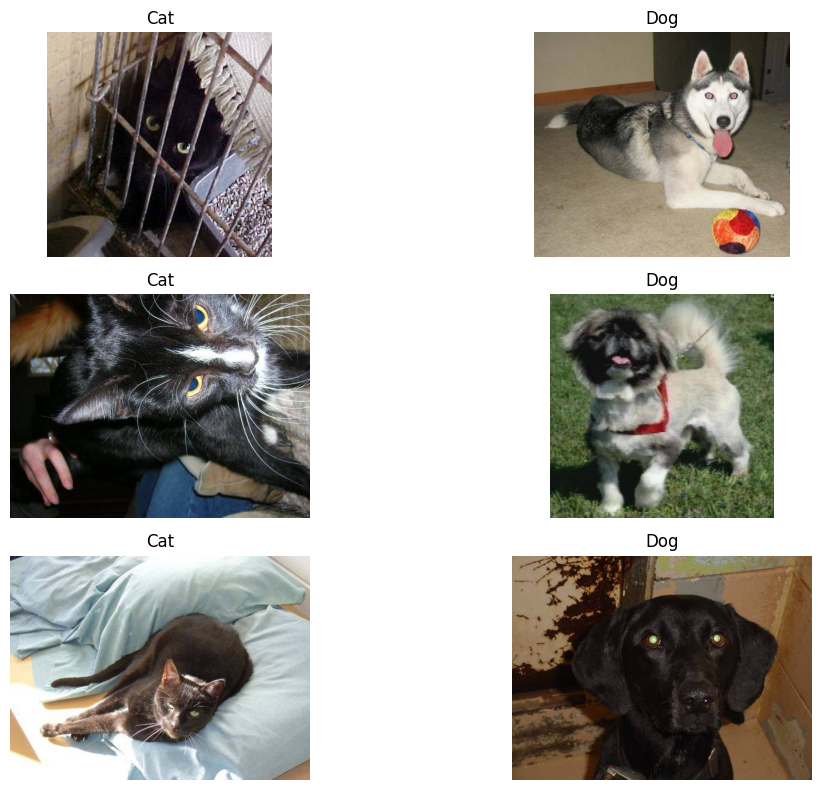

In [ ]:
cat = df[df["label"]==0]
dog = df[df["label"]==1]

cat_sample = cat.sample(n=3,random_state=42)["image_path"].tolist()
dog_sample = dog.sample(n=3,random_state=42)["image_path"].tolist()


# plotting images
fig,axes = plt.subplots(3,2,figsize=(12,8))
for i in range(3):
    # plotting cat image
    img = Image.open(cat_sample[i])
    axes[i,0].imshow(img)
    axes[i,0].axis("off")
    axes[i,0].set_title("Cat")

    # plotting dog image
    img = Image.open(dog_sample[i])
    axes[i,1].imshow(img)
    axes[i,1].axis("off")
    axes[i,1].set_title("Dog")

plt.tight_layout()
plt.show()

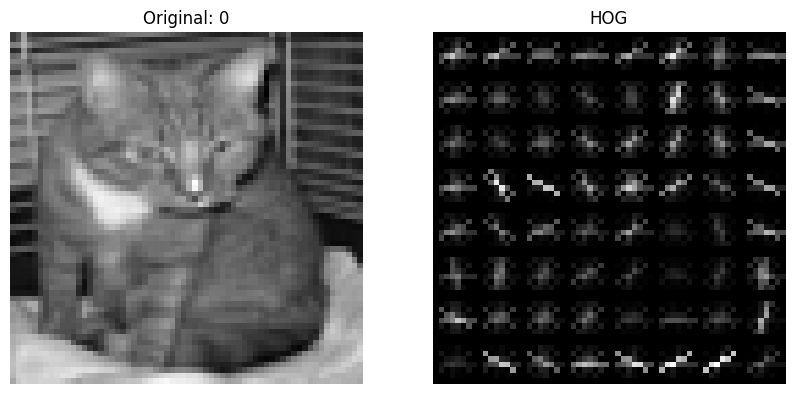

In [9]:
from skimage.feature import hog
from skimage import exposure

idx=0
img_path = df.iloc[idx]["image_path"]
label = df.iloc[idx]["label"]

img = Image.open(img_path).convert("L")
img = img.resize((64,64))
img_arr = np.array(img, dtype=np.float32) / 255.0

hog_feat, hog_image = hog(
    img_arr,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    visualize=True, #returns a HOG image suitable for plotting
    channel_axis=None
)

#  rescales values so the HOG image is visible nicely
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_arr, cmap="gray")
axes[0].axis("off")
axes[0].set_title(f"Original: {label}")

axes[1].imshow(hog_image_rescaled, cmap="gray")
axes[1].axis("off")
axes[1].set_title("HOG")

plt.show()

# Droping Data

In [ ]:
# n_samples_per_class = 4000
# df_reduced = df.groupby("label").sample(n=n_samples_per_class, random_state=42).reset_index(drop=True)

``HOG finds edges and uses those edges as features``

In [10]:
# HOG finds edges and uses those edges as features
def preprocess(img_size):
    x = []
    y = []

    for idx,row in df.iterrows():
        img_path = row["image_path"]
        label = row["label"]

        # Open image and convert to gray scale as hog take grayscale image
        img = Image.open(img_path).convert("L")

        # Resize
        img = img.resize(img_size)

        # Convert to numpy array and normalize
        img_arr = np.array(img, dtype=np.float32) / 255.0

        #HOG (Histogram of Oriented Gradients)
        #Uses edge directions & intensity changes (it require grayscale blcak and white image)
        #Color information is NOT required
        hog_feat = hog(
            img_arr,
            orientations=9 ,# number of bins in the histogram(more orientation more detail shape info)
            pixels_per_cell = (8,8), #image is divided in to samll cell of (8,8) =>64 cells
            cells_per_block = (2,2),
            block_norm = "L2-Hys", # normalization(l2 norm(eucledian distance))
            channel_axis=None  # the image has no channel axis (H x W)
        )

        x.append(hog_feat)
        y.append(label)

    return np.array(x),np.array(y)



x,y = preprocess(img_size=(64,64))
print(x.shape, y.shape)

(25000, 1764) (25000,)


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
# from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA


x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print(f"x_train: {x_train.shape} , y_train: {y_train.shape}")
print(f"x_test:  {x_test.shape}  , y_test:  {y_test.shape}")

x_train: (20000, 1764) , y_train: (20000,)
x_test:  (5000, 1764)  , y_test:  (5000,)


In [12]:
def evaluation_metrics(model,x_train,y_train,cv,y_test,y_pred):

    # Training metrices
    y_train_pred = model.predict(x_train)
    train_accuracy = accuracy_score(y_train,y_train_pred)

    # testing metrics
    test_accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    cm = confusion_matrix(y_test,y_pred)

    cv_scores = cross_val_score(model, x_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_mean = np.mean(cv_scores)

    return {
        "Training Accuracy": f"{train_accuracy:.2f}",
        "Testing Accuracy": f"{test_accuracy:.2f}",
        "Precision Score": f"{precision:.2f}",
        "Recall Score": f"{recall:.2f}",
        "CV Mean Accuracy": f"{cv_mean:.2f}",
        "Confusion Matrix": cm
    }


# Support Vector Machine

In [13]:
from sklearn.svm import SVC

pipeline_svm = Pipeline([
    ("scaler",StandardScaler()), # scale features
    ("pca", PCA(n_components=0.97)),
    ("svm",SVC(kernel='rbf', C=1.0, gamma='scale')) # classifier c:regularization
])

orignal components: 1764 | Components after PCA 565
Training Accuracy : 0.94

Testing Accuracy : 0.78

Precision Score : 0.77

Recall Score : 0.78

CV Mean Accuracy : 0.77

Confusion Matrix : [[1941  574]
 [ 550 1935]]



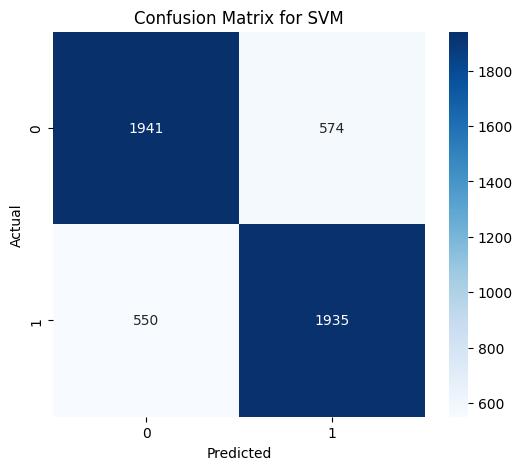

In [14]:
pipeline_svm.fit(x_train,y_train)
y_pred = pipeline_svm.predict(x_test)

n_comp = pipeline_svm.named_steps["pca"].n_components_
print(f"orignal components: {x_train.shape[1]} | Components after PCA {n_comp}")

metrics = evaluation_metrics(pipeline_svm,x_train,y_train,5,y_test,y_pred)
for key,value in metrics.items():
    print(f"{key} : {value}\n")

plt.figure(figsize=(6,5))
sns.heatmap(metrics["Confusion Matrix"], annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for SVM")
plt.show()

In [ ]:
import joblib
joblib.dump(pipeline_svm,"svm_pipeline")

['svm_pipeline']

# Random Forest

In [15]:
pipeline_rf = Pipeline([
    ("scaler",StandardScaler()), # scale features
    ("pca", PCA(n_components=0.97)),
    ("rf",RandomForestClassifier(n_estimators=278, max_depth=13,min_samples_split=5, random_state=42)) # classifier
])

# from optuna hyperparameter
#  {'n_estimators': 278, 'max_depth': 13, 'min_samples_split': 5}
# Optuna best score: 0.7216

orignal components: 1764 | Components after PCA 565
Training Accuracy : 0.99

Testing Accuracy : 0.72

Precision Score : 0.71

Recall Score : 0.74

CV Mean Accuracy : 0.71

Confusion Matrix : [[1773  742]
 [ 650 1835]]



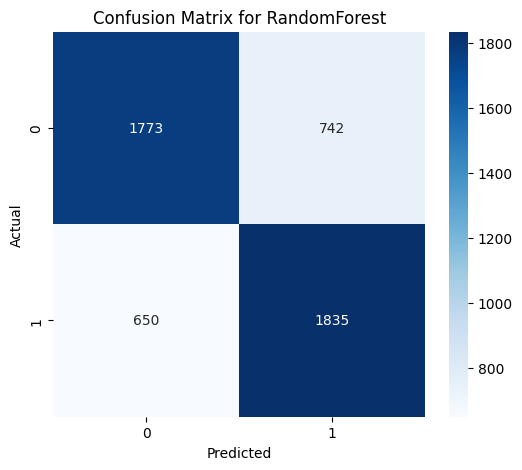

In [16]:
pipeline_rf.fit(x_train,y_train)
y_pred = pipeline_rf.predict(x_test)

n_comp = pipeline_rf.named_steps["pca"].n_components_
print(f"orignal components: {x_train.shape[1]} | Components after PCA {n_comp}")

metrics = evaluation_metrics(pipeline_rf,x_train,y_train,5,y_test,y_pred)
for key,value in metrics.items():
    print(f"{key} : {value}\n")


plt.figure(figsize=(6,5))
sns.heatmap(metrics["Confusion Matrix"], annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for RandomForest")
plt.show()

In [ ]:
import joblib
joblib.dump(pipeline_rf,"rf_pipeline")

['rf_pipeline']

# K-Nearest Neighbour

In [17]:
pipeline_knn = Pipeline([
    ("scaler",StandardScaler()), # scale features
    ("pca", PCA(n_components=0.97)),
    ("knn",KNeighborsClassifier(n_neighbors=4)) # classifier
])

Training Accuracy : 0.80

Testing Accuracy : 0.65

Precision Score : 0.60

Recall Score : 0.86

CV Mean Accuracy : 0.64

Confusion Matrix : [[1102 1413]
 [ 346 2139]]



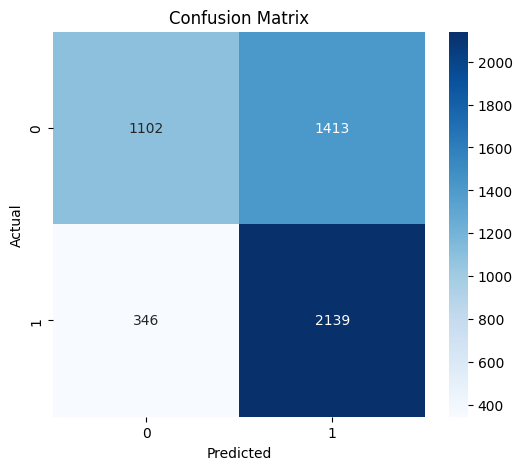

In [18]:
pipeline_knn.fit(x_train,y_train)
y_pred = pipeline_knn.predict(x_test)

metrics = evaluation_metrics(pipeline_knn,x_train,y_train,5,y_test,y_pred)
for key,value in metrics.items():
    print(f"{key} : {value}\n")

plt.figure(figsize=(6,5))
sns.heatmap(metrics["Confusion Matrix"], annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import joblib
joblib.dump(pipeline_knn,"knn_pipeline")

['knn_pipeline']

# Hyper Parameter Tunning

In [ ]:
!pip install optuna -q

In [ ]:
import optuna

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 2, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)

    # for monitoring progress
    print("\n" + "*"*50)
    print(f"Trial {trial.number}: Testing n_estimators={n_estimators}, max_depth={max_depth}, min_samples_split={min_samples_split}")
    print("*"*50 + "\n")

    pipeline_rf = Pipeline([
        ("scaler",StandardScaler()), # scale features
        ("pca", PCA(n_components=0.97)),
        ("rf",RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth,min_samples_split=min_samples_split, random_state=42)) # classifier
    ])
    pipeline_rf.fit(x_train,y_train)
    y_pred = pipeline_rf.predict(x_test)
    return accuracy_score(y_test,y_pred)

#createing study
study = optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(),study_name="RandomForest-Trials")

study.optimize(objective, n_trials=25)  # number of trials

print("Optuna best params:", study.best_params)
print("Optuna best score:", study.best_value)

[I 2026-01-18 10:05:21,438] A new study created in memory with name: RandomForest-Trials



**************************************************
Trial 0: Testing n_estimators=141, max_depth=8, min_samples_split=2
**************************************************



[I 2026-01-18 10:06:58,278] Trial 0 finished with value: 0.7082 and parameters: {'n_estimators': 141, 'max_depth': 8, 'min_samples_split': 2}. Best is trial 0 with value: 0.7082.



**************************************************
Trial 1: Testing n_estimators=50, max_depth=12, min_samples_split=10
**************************************************



[I 2026-01-18 10:07:48,090] Trial 1 finished with value: 0.6876 and parameters: {'n_estimators': 50, 'max_depth': 12, 'min_samples_split': 10}. Best is trial 0 with value: 0.7082.


...


**************************************************
Trial 23: Testing n_estimators=203, max_depth=13, min_samples_split=6
**************************************************



[I 2026-01-18 11:05:02,303] Trial 23 finished with value: 0.7108 and parameters: {'n_estimators': 203, 'max_depth': 13, 'min_samples_split': 6}. Best is trial 4 with value: 0.7216.



**************************************************
Trial 24: Testing n_estimators=279, max_depth=5, min_samples_split=6
**************************************************



[I 2026-01-18 11:06:47,020] Trial 24 finished with value: 0.7066 and parameters: {'n_estimators': 279, 'max_depth': 5, 'min_samples_split': 6}. Best is trial 4 with value: 0.7216.


Optuna best params: {'n_estimators': 278, 'max_depth': 13, 'min_samples_split': 5}
Optuna best score: 0.7216


# SVM

In [ ]:
import optuna
from sklearn.svm import SVC

# ply kernel is slow and higher value of c is also slow
def objective(trial):
    C = trial.suggest_float('C', 0.1, 10.0, log=True)           # regularization
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf'])
    gamma = trial.suggest_float('gamma', 1e-4, 1e-2, log=True)  # only used for rbf, poly, sigmoid

    # for monitoring progress
    print("\n" + "*"*50)
    print(f"Trial {trial.number}: Testing C={C:.4f}, gamma={gamma:.4f}, kernel={kernel}")
    print("*"*50 + "\n")

    # Create SVM with suggested hyperparameters
    if kernel in ['rbf']:
        svm_clf = SVC(C=C, kernel=kernel, gamma=gamma)
    else:
        svm_clf = SVC(C=C, kernel=kernel)

    # creating svm pipline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)),
        ('svm', svm_clf)
    ])

    # fit and predict
    pipeline.fit(x_train, y_train)
    y_pred = pipeline.predict(x_test)

    return accuracy_score(y_test,y_pred)


#createing study
study = optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(),study_name="SVM-Trials")

study.optimize(objective, n_trials=20)  # number of trials

print("Optuna best params:", study.best_params)
print("Optuna best score:", study.best_value)

[I 2026-01-18 13:44:31,225] A new study created in memory with name: SVM-Trials



**************************************************
Trial 0: Testing C=9.0286, gamma=0.0026, kernel=rbf
**************************************************



[I 2026-01-18 14:02:58,381] Trial 0 finished with value: 0.7116 and parameters: {'C': 9.028608498691995, 'kernel': 'rbf', 'gamma': 0.0026206516084413506}. Best is trial 0 with value: 0.7116.



**************************************************
Trial 1: Testing C=0.1081, gamma=0.0003, kernel=rbf
**************************************************



[I 2026-01-18 14:07:32,316] Trial 1 finished with value: 0.7386 and parameters: {'C': 0.1081356936300342, 'kernel': 'rbf', 'gamma': 0.00025515769401367606}. Best is trial 1 with value: 0.7386.



**************************************************
Trial 2: Testing C=0.8150, gamma=0.0015, kernel=rbf
**************************************************



[I 2026-01-18 14:17:42,130] Trial 2 finished with value: 0.758 and parameters: {'C': 0.8149554669156317, 'kernel': 'rbf', 'gamma': 0.001470406536808535}. Best is trial 2 with value: 0.758.



**************************************************
Trial 3: Testing C=0.4650, gamma=0.0001, kernel=rbf
**************************************************



[I 2026-01-18 14:21:56,322] Trial 3 finished with value: 0.74 and parameters: {'C': 0.4650494131228212, 'kernel': 'rbf', 'gamma': 0.00010873052092757236}. Best is trial 2 with value: 0.758.



**************************************************
Trial 4: Testing C=2.1013, gamma=0.0023, kernel=linear
**************************************************



# HOG(Histogram of Oriented Gradient)
``Histogram--> Histogram``  
`` Oriented --> andle(theta)``  
``Gradient --> Edges``  

**HOG finds edges and uses those edges as features**

**It find the edges angle thats why known as oriented gradient(orientation of edges)**

Instead of using raw pixels,HOG ansers
where are the edges and in which direction

steps:
1. convert image to gray scale
2. Divide the image in to smaller cells(e.g 8 8)
2. Compute graident in x and y diretion (how pixel intensity is changing-> so we can find the edges)
3. Group gradient in to small region
4. Build histogram
5. normalize for lightining change


Gradient(edges):  
Compute intensity change in x-direction and y-direction
This gives:  
``Magnitude → how strong the edge is``  
``Orientation → which direction the edge points``  
Example:    
``Vertical edge → strong horizontal gradient``  
``Horizontal edge → strong vertical gradient``  

https://youtu.be/5nZGnYPyKLU?si=JTD3-hbW_2jZi8B6

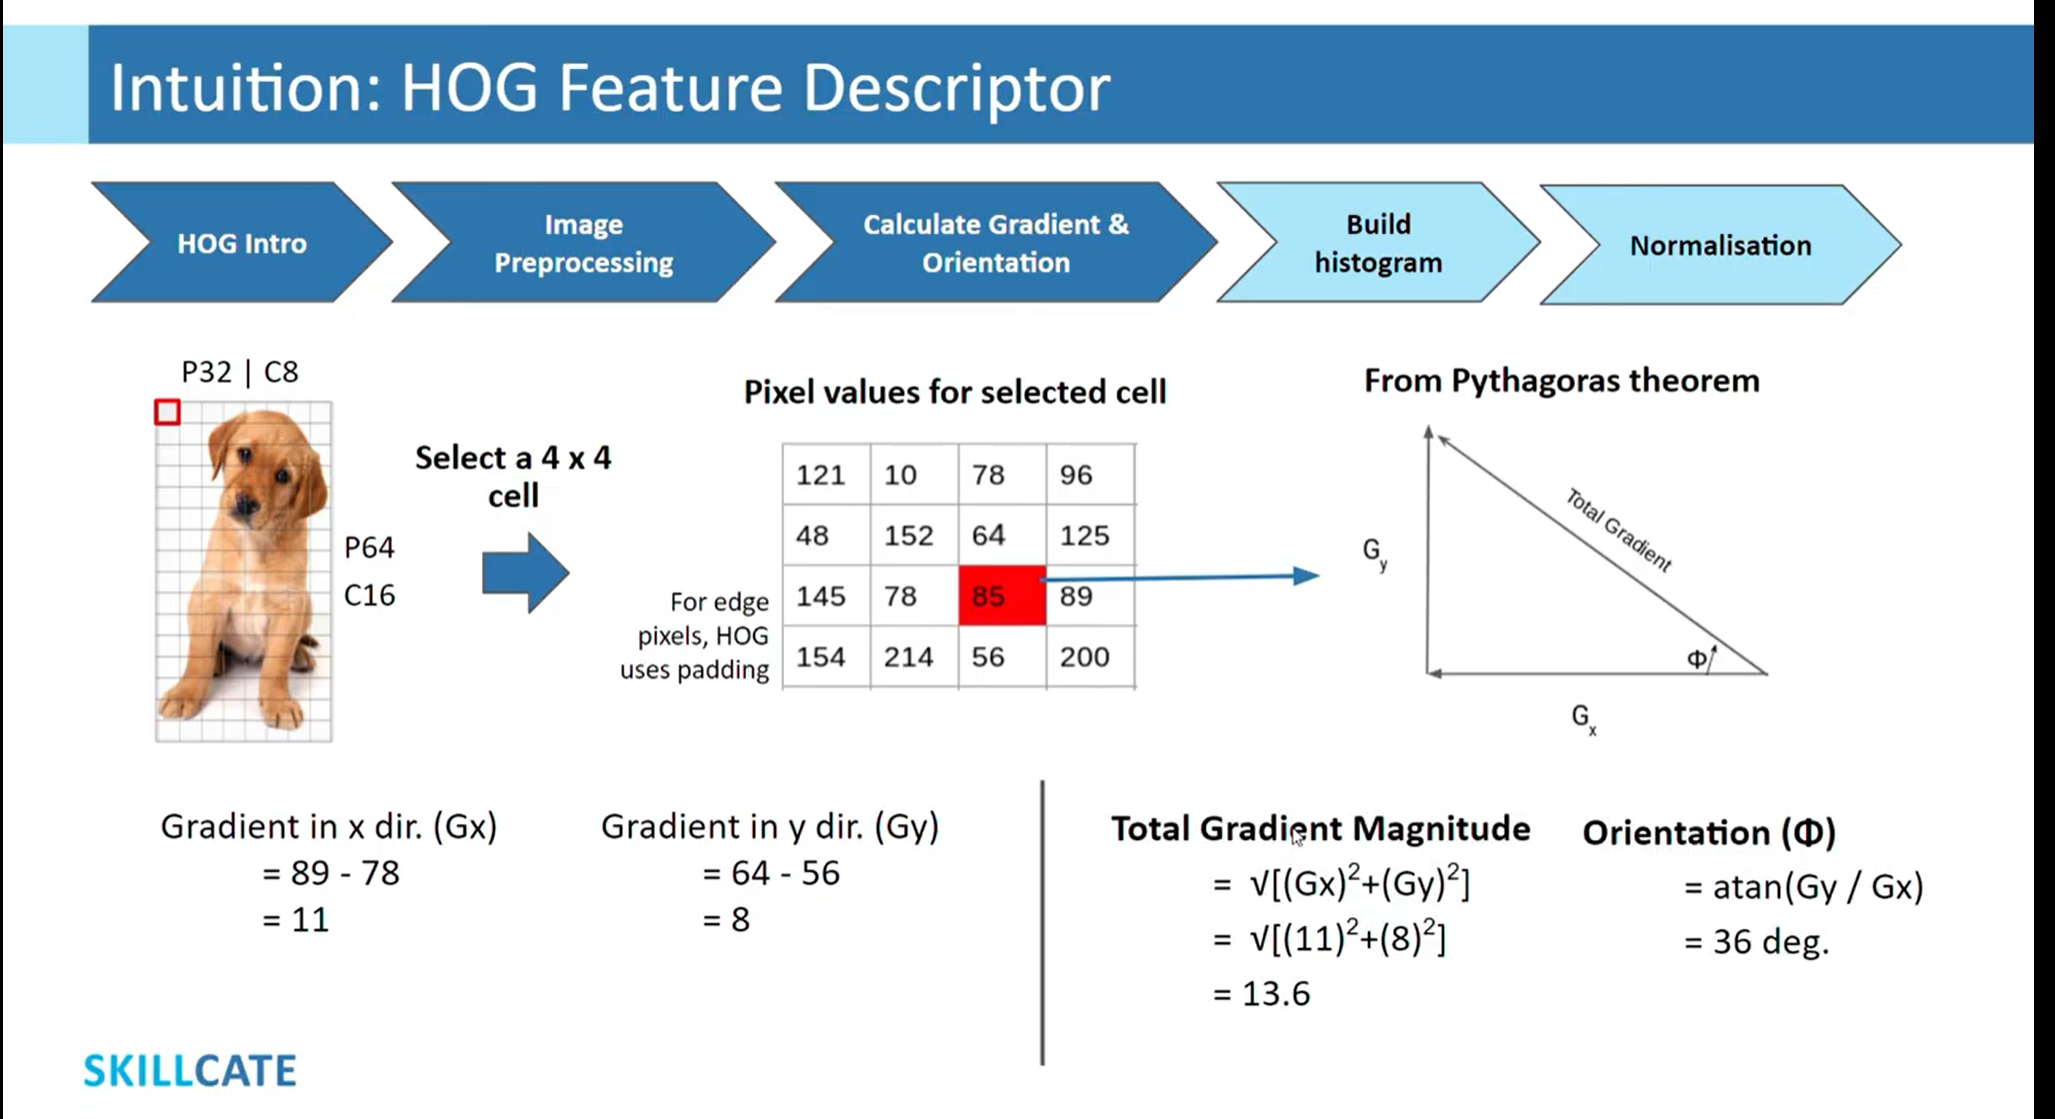

In [ ]:
hog_feat = hog(
    img_arr,
    orientations=9 ,
    pixels_per_cell = (8,8),
    cells_per_block = (2,2),
    block_norm = "L2-Hys", # normalization(l2 norm(eucledian distance))
    channel_axis=None  # the image has no channel axis (H x W)
        )


``orientation --> Gradient angles are divided into 9 bins ``  
``pixel per cell --> Image is divided into 8×8 pixel cells --> For each cell, a histogram of gradients is computed ``    

``cells per block(2,2)--> 2 cells wide × 2 cells high --> Each block contains 4 cells``    

* Each cell → 9-bin histogram  
* Block → 4 × 9 = 36 values